# CS 6330 Data Science Project

**Project Title**: Global Aviation Infrastructure Analysis

*   Name: Voleak Lim
*   CID: 81488194
*   Contact: vlim2@angelo.edu
*   GitHub: https://github.com/limvoleak1128/CS-6330-aviation-project

*   Project idea: This project examines how physical infrastructure shapes global air connectivity. Specifically, it investigates whether airport elevation, geographic position, and airport size influence the distance and type of routes an airport can support. Rather than treating aviation purely as
an economic or demand-driven network, this analysis approaches it from
an infrastructure perspective — asking whether the physical characteristics
of an airport constrain or define its role in the global flight network. By integrating airline, airport, and route data, the project applies
regression, classification, and clustering methods to uncover patterns
that predefined labels and conventional assumptions do not fully capture.

# Dataset

- URL: https://www.kaggle.com/datasets/darkmatternet/global-flights-airports-airlines/data?select=airlines.csv
- Description:This dataset integrates three primary aviation files: Airports, Airlines, and Routes. By combining crowdsourced airport and airline data with commercial route information, the dataset provides a comprehensive view of global connectivity, including small regional airfields and inactive carriers.
- Columns and key features:
  1. Airports Table (85,116 rows × 19 columns): elevation_ft, type, continent iso_country, and iata_code
  2. Airlines Table (1,536 rows × 8 columns): callsign, airline_name, and iata_code
  3. Routes Table (66,379 rows × 19 columns): distance_km, airline_name, src_iata, dst_iata, airline_iata, src_country, and dst_country
- Merged Identifiers:  IATA codes used by airlines and airports, including IATA 2-letter and 3-letter codes.

## Project Goals
This project investigates global aviation through five analytical goals:

1. Data Integration: Successfully merge the airlines, airports, and routes
   datasets into a single unified master dataset for analysis.

2. Infrastructure Analysis: Investigate whether source airport elevation
   significantly influences route distance, using latitude and longitude
   as geographic supporting features.

3. Route Type Analysis: Classify routes as domestic or international based on
   geographic and infrastructure features.

4. Traffic Dominance Analysis: Identify the top countries by total inbound
   and outbound flight volume, detect countries where a single airline controls
   more than 70% of routes, and map the most intense continent-to-continent
   traffic corridors.

5. Capacity Analysis: Examine whether medium-sized airports exist that handle
   a disproportionately high number of routes relative to large airports,
   challenging the assumption that airport size determines route capacity.

6. Missing Value Study: Investigate whether empty callsign entries represent
   unrecorded data or airlines that genuinely operate without a callsign.
   **Note**: This goal was set aside during the discovery phase after revealing
   395 missing values, making manual verification impractical. The missing
   values are handled with an 'Unknown' placeholder instead.

This notebook covers the regression analysis section of the project.
The necessary libraries are loaded below, along with the cleaned and
merged dataset produced in exploration.ipynb.

In [ ]:
# ── Standard libraries ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore")

# ── Visualization ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats

# ── Scikit-learn: Models ──────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression

# ── Scikit-learn: Preprocessing & Model Selection ─────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Scikit-learn: Metrics ─────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    log_loss, accuracy_score, classification_report, confusion_matrix
)

In [ ]:
# ── Mount Google Drive to access dataset files stored in Drive ────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Define file path and load the the merge dataset into dataframes ─────
path = '/content/drive/My Drive/CS-6330-aviation-project/dataset/final_cleaned_flight_data.csv'

master_df = pd.read_csv(path)     # cleaned and merged dataset produced in exploration.ipynb

# 2. Regression

During initial exploration, the scatter plot of distance_km vs. src_elevation
revealed a weak linear correlation, confirming that elevation alone cannot
explain the vast differences in global flight distances. However, rather than
dropping elevation, we incorporate latitude and longitude as supporting features  based on a key insight: an airport's altitude is geographically dependent —  high-elevation airports tend to cluster in specific regions

The three features each capture a different dimension of airport infrastructure:
- src_elevation: the vertical dimension — higher altitudes impose physical
  constraints on aircraft operations and connectivity.
- src_lat: the north-south position — major economic hubs are historically
  concentrated in specific latitudinal bands, particularly the Northern Hemisphere.
- src_lon: the east-west position — allows the model to capture the major
  transcontinental corridors that define global flight flow.

Two geographic supporting features are engineered from
the existing latitude and longitude columns: `lat_diff` (the absolute difference in latitude between source and destination airports) and `lon_diff` (the absolute difference in longitude).

A binary target variable `is_international` is also
created, where 1 indicates the route crosses a country border and 0 indicates
a domestic route.

In [ ]:
# Feature engineering
master_df['lat_diff'] = abs(master_df['dst_lat'] - master_df['src_lat'])
master_df['lon_diff'] = abs(master_df['dst_lon'] - master_df['src_lon'])
master_df['is_international'] = (master_df['src_country'] != master_df['dst_country']).astype(int)

print('New features added: lat_diff, lon_diff, is_international')
print(master_df[['src_elevation', 'dst_elevation', 'lat_diff', 'lon_diff', 'distance_km', 'is_international']].describe())

New features added: lat_diff, lon_diff, is_international
       src_elevation  dst_elevation      lat_diff      lon_diff   distance_km  \
count   66378.000000   66378.000000  6.637800e+04  66378.000000  66378.000000   
mean      232.421679     233.397661  9.039284e+00     17.126631   1842.588508   
std       453.298653     454.103476  9.958137e+00     31.940994   2025.654164   
min       -21.945600     -21.945600  1.600000e-07      0.000045      3.000000   
25%        10.972800      10.972800  2.512242e+00      3.199259    617.000000   
50%        53.949600      53.949600  6.201318e+00      7.614005   1184.000000   
75%       207.568800     208.788000  1.215340e+01     17.007709   2159.000000   
max      4411.065600    4411.065600  8.713080e+01    359.217586  13808.000000   

       is_international  
count      66378.000000  
mean           0.509175  
std            0.499920  
min            0.000000  
25%            0.000000  
50%            1.000000  
75%            1.000000  
max  

**Project Goal**: Infrastructure Analysis: Investigate whether source airport elevation significantly influences route distance, using latitude and longitude as geographic supporting features (Single Linear Regression and Multiple Linear Regression).


## 2.1 Single Linear Regression

The Question: Does airport elevation significantly impact the distance of routes?

Use LinearRegression to examine whether airport elevation
at the source airport (src_elevation) can predict the route distance (distance_km). Elevation is selected as the independent variable because it is the primary infrastructure feature of interest in this project. The dataset is split into 80% training and 20% testing sets. Model performance
is measured using MSE, RMSE, and MAE, and the results are visualised with
a regression line plot and an observed vs predicted scatter plot.

In [ ]:
# ── Data preparation ───────────────────────────────────────────────────────
slr_data = master_df[['src_elevation', 'distance_km']].dropna()

X_slr = slr_data[['src_elevation']].values
y_slr = slr_data['distance_km'].values

X_slr_train, X_slr_test, y_slr_train, y_slr_test = train_test_split(
    X_slr, y_slr, test_size=0.2, random_state=42
)

# ── Model ──────────────────────────────────────────────────────────────────
slr_model = LinearRegression()
slr_model.fit(X_slr_train, y_slr_train)

y_slr_pred = slr_model.predict(X_slr_test)

print('Simple Linear Regression: src_elevation → distance_km')
print(f'  Intercept  : {slr_model.intercept_:.4f}')
print(f'  Coefficient: {slr_model.coef_[0]:.4f}  (src_elevation)')
print(f'  R²         : {r2_score(y_slr_test, y_slr_pred):.4f}')

Simple Linear Regression: src_elevation → distance_km
  Intercept  : 1918.4514
  Coefficient: -0.3075  (src_elevation)
  R²         : 0.0048


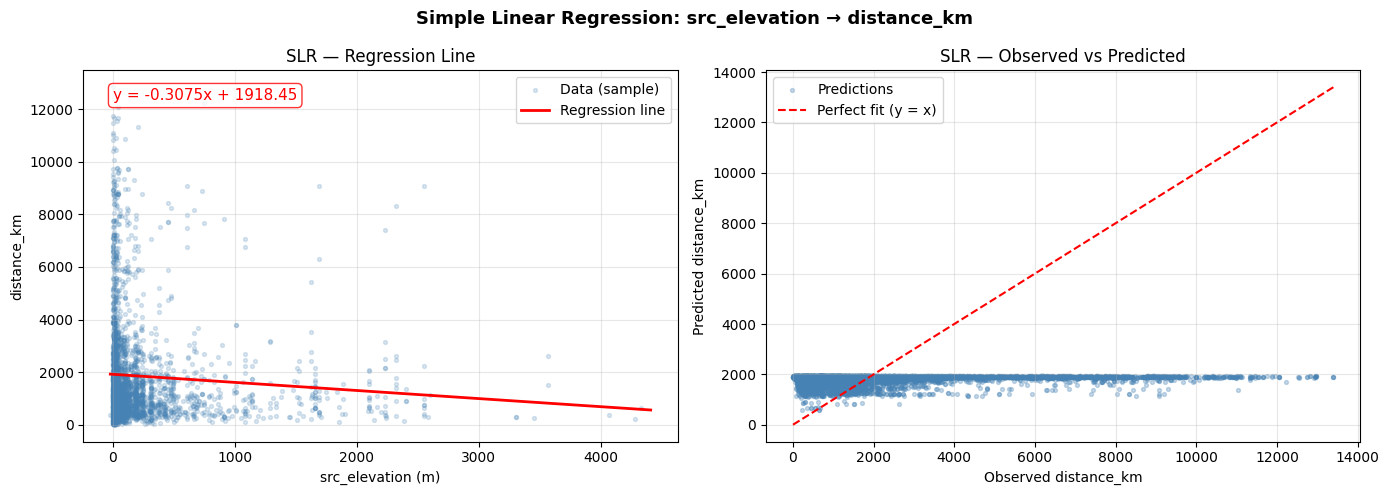

In [ ]:
# ── Plot: Observed vs Predicted ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: regression line over scatter
ax1 = axes[0]
sample = slr_data.sample(3000, random_state=42)
ax1.scatter(sample['src_elevation'], sample['distance_km'],
            alpha=0.2, s=8, color='steelblue', label='Data (sample)')
x_line = np.linspace(X_slr.min(), X_slr.max(), 200).reshape(-1, 1)
ax1.plot(x_line, slr_model.predict(x_line), color='red', linewidth=2,
         label='Regression line')
ax1.set_xlabel('src_elevation (m)')
ax1.set_ylabel('distance_km')
ax1.set_title('SLR — Regression Line')
ax1.legend()
ax1.grid(alpha=0.3)

# Build equation string
intercept  = slr_model.intercept_
coef       = slr_model.coef_[0]
sign       = '+' if intercept >= 0 else '-'
equation   = f'y = {coef:.4f}x {sign} {abs(intercept):.2f}'

# Place it on the plot
ax1.text(
    0.05, 0.92, equation,
    transform=ax1.transAxes,
    fontsize=11,
    color='red',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8)
)

# Right: observed vs predicted
ax2 = axes[1]
ax2.scatter(y_slr_test, y_slr_pred, alpha=0.3, s=8, color='steelblue', label='Predictions')
lims = [min(y_slr_test.min(), y_slr_pred.min()), max(y_slr_test.max(), y_slr_pred.max())]
ax2.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit (y = x)')
ax2.set_xlabel('Observed distance_km')
ax2.set_ylabel('Predicted distance_km')
ax2.set_title('SLR — Observed vs Predicted')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Simple Linear Regression: src_elevation → distance_km',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Loss functions ─────────────────────────────────────────────────────────
slr_mse  = mean_squared_error(y_slr_test, y_slr_pred)
slr_rmse = np.sqrt(slr_mse)
slr_mae  = mean_absolute_error(y_slr_test, y_slr_pred)
slr_r2   = r2_score(y_slr_test, y_slr_pred)

print('SLR Loss Functions')
print(f'  MSE  : {slr_mse:>12,.2f}')
print(f'  RMSE : {slr_rmse:>12,.2f}')
print(f'  MAE  : {slr_mae:>12,.2f}')
print(f'  R²   : {slr_r2:>12,.4f}')

SLR Loss Functions
  MSE  : 3,968,694.88
  RMSE :     1,992.16
  MAE  :     1,340.45
  R²   :       0.0048


**Interpretation of Results**

Elevation alone shows a weak negative relationship with route distance (r^2 =  0.0048). The low R² is expected and honest — it tells us that airport altitude by itself is not a strong predictor of how far a route flies. This motivates the multiple regression, where we control for geographic position to better isolate elevation's true contribution.

## 2.2 Multiple Linear Regression

The Question: Can we predict how long a flight route is, using elevation and geographic position together?

In [ ]:
# ── Data preparation ───────────────────────────────────────────────────────
mlr_features = ['src_elevation', 'dst_elevation', 'lat_diff', 'lon_diff']
mlr_data = master_df[mlr_features + ['distance_km']].dropna()

X_mlr = mlr_data[mlr_features].values
y_mlr = mlr_data['distance_km'].values

X_mlr_train, X_mlr_test, y_mlr_train, y_mlr_test = train_test_split(
    X_mlr, y_mlr, test_size=0.2, random_state=42
)

# ── Model ──────────────────────────────────────────────────────────────────
mlr_model = LinearRegression()
mlr_model.fit(X_mlr_train, y_mlr_train)

y_mlr_pred = mlr_model.predict(X_mlr_test)

print('Multiple Linear Regression')
print(f'  R²: {r2_score(y_mlr_test, y_mlr_pred):.4f}')
print('\n  Coefficients:')
for feat, coef in zip(mlr_features, mlr_model.coef_):
    print(f'    {feat:<20}: {coef:.4f}')
print(f'  Intercept: {mlr_model.intercept_:.4f}')

# ── Print equation ─────────────────────────────────────────────────────────
terms = []
for feat, coef in zip(mlr_features, mlr_model.coef_):
    sign = '+' if coef >= 0 else '-'
    terms.append(f'{sign} {abs(coef):.4f}×{feat}')

intercept_sign = '+' if mlr_model.intercept_ >= 0 else '-'
equation = (f'\n  Equation:\n  distance_km = '
            + ' '.join(terms)
            + f' {intercept_sign} {abs(mlr_model.intercept_):.2f}')
print(equation)

Multiple Linear Regression
  R²: 0.8468

  Coefficients:
    src_elevation       : 0.0160
    dst_elevation       : 0.0170
    lat_diff            : 97.1345
    lon_diff            : 41.7833
  Intercept: 242.2077

  Equation:
  distance_km = + 0.0160×src_elevation + 0.0170×dst_elevation + 97.1345×lat_diff + 41.7833×lon_diff + 242.21


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = mlr_features
vif_data['VIF'] = [variance_inflation_factor(X_mlr_train, i)
                   for i in range(X_mlr_train.shape[1])]
print('\n  Variance Inflation Factor (VIF):')
print(vif_data.to_string(index=False))
print('\n  (VIF > 10 indicates high multicollinearity)')


  Variance Inflation Factor (VIF):
      Feature      VIF
src_elevation 1.227319
dst_elevation 1.227175
     lat_diff 1.438180
     lon_diff 1.342190

  (VIF > 10 indicates high multicollinearity)


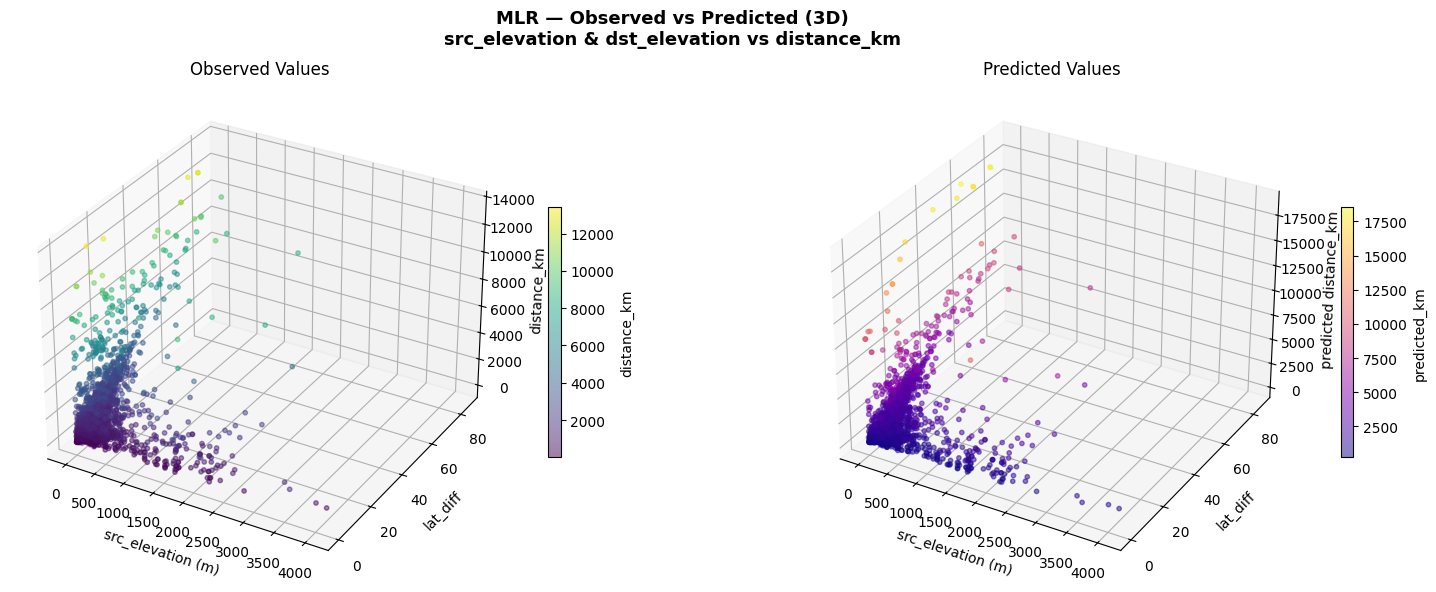

In [ ]:
# ── 3D Plot: src_elevation & lat_diff vs distance_km ──────────────────
sample_idx = np.random.choice(len(X_mlr_test), size=min(2000, len(X_mlr_test)), replace=False)
X_plot     = X_mlr_test[sample_idx]
y_obs      = y_mlr_test[sample_idx]
y_pred_plot = y_mlr_pred[sample_idx]

# src_elevation = index 0, lat_diff = index 2
elev_src = X_plot[:, 0]
lat      = X_plot[:, 2]
fig = plt.figure(figsize=(16, 6))

# Subplot 1: Observed
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(elev_src, lat, y_obs,
                  c=y_obs, cmap='viridis', alpha=0.5, s=10)
ax1.set_xlabel('src_elevation (m)')
ax1.set_ylabel('lat_diff')
ax1.set_zlabel('distance_km')
ax1.set_title('Observed Values')
fig.colorbar(sc1, ax=ax1, shrink=0.5, label='distance_km')

# Subplot 2: Predicted
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(elev_src, lat, y_pred_plot,
                  c=y_pred_plot, cmap='plasma', alpha=0.5, s=10)
ax2.set_xlabel('src_elevation (m)')
ax2.set_ylabel('lat_diff')
ax2.set_zlabel('predicted distance_km')
ax2.set_title('Predicted Values')
fig.colorbar(sc2, ax=ax2, shrink=0.5, label='predicted_km')

fig.suptitle('MLR — Observed vs Predicted (3D)\nsrc_elevation & dst_elevation vs distance_km',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Loss functions ─────────────────────────────────────────────────────────
mlr_mse  = mean_squared_error(y_mlr_test, y_mlr_pred)
mlr_rmse = np.sqrt(mlr_mse)
mlr_mae  = mean_absolute_error(y_mlr_test, y_mlr_pred)
mlr_r2   = r2_score(y_mlr_test, y_mlr_pred)

print('MLR Loss Functions')
print(f'  MSE  : {mlr_mse:>12,.2f}')
print(f'  RMSE : {mlr_rmse:>12,.2f}')
print(f'  MAE  : {mlr_mae:>12,.2f}')
print(f'  R²   : {mlr_r2:>12,.4f}')

MLR Loss Functions
  MSE  :   610,812.53
  RMSE :       781.54
  MAE  :       345.35
  R²   :       0.8468


**Interpretation of Results**

Adding lat/lon differences alongside both elevation features significantly improves R² (0.8468) compared to SLR (0.0048).

The sign change on src_elevation between the simple and multiple regression models is a natural consequence of adding new features, not a sign of problematic multicollinearity — the VIF scores for all four features fall between 1.2 and 1.4, confirming that the features are largely independent of each other. In the simple model, src_elevation was the only predictor, so it unintentionally absorbed some geographic variation alongside its own effect. Once lat_diff and lon_diff were introduced, they took over the geographic explanation, leaving src_elevation to reflect only its own small, isolated effect on route distance — which settles at +0.016, a practically negligible value. This is precisely why incorporating latitude and longitude as supporting features is necessary — it allows elevation's true contribution to be studied in its proper geographic context, rather than as a mixed signal.

## 2.3 Logistic Regression

**Project Goal**: Route Type Analysis: Classify airlines as primarily domestic or international based on their route portfolios.

The Question: Can we predict whether a route is international or domestic, based on elevation and distance?

LogisticRegression to classify whether a flight route
is international (crossing a country border) or domestic (within the same country).  The target variable is_international is binary: 1 for international and 0 for domestic. The features used are src_elevation, dst_elevation, and distance_km — keeping elevation as the central focus while distance provides additional discriminative signal. Features are standardised using StandardScaler before fitting, as logistic regression is sensitive to feature scale. erformance is reported using absolute loss and log loss, and results are visualised through a predicted probability distribution and a
scatter plot coloured by predicted class.

In [ ]:
# ── Data preparation ───────────────────────────────────────────────────────
log_features = ['src_elevation', 'dst_elevation', 'distance_km']
log_data = master_df[log_features + ['is_international']].dropna()

X_log = log_data[log_features].values
y_log = log_data['is_international'].values

X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

# Scale (important for logistic regression)
scaler = StandardScaler()
X_log_train_sc = scaler.fit_transform(X_log_train)
X_log_test_sc  = scaler.transform(X_log_test)

# ── Model ──────────────────────────────────────────────────────────────────
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_log_train_sc, y_log_train)

y_log_pred       = log_model.predict(X_log_test_sc)
y_log_pred_proba = log_model.predict_proba(X_log_test_sc)[:, 1]

print('Logistic Regression: src_elevation + dst_elevation + distance_km → is_international')
print(f'  Accuracy: {np.mean(y_log_pred == y_log_test):.4f}')
print('\n  Coefficients:')
for feat, coef in zip(log_features, log_model.coef_[0]):
    print(f'    {feat:<20}: {coef:.4f}')

Logistic Regression: src_elevation + dst_elevation + distance_km → is_international
  Accuracy: 0.7278

  Coefficients:
    src_elevation       : -0.2263
    dst_elevation       : -0.2187
    distance_km         : 1.9560


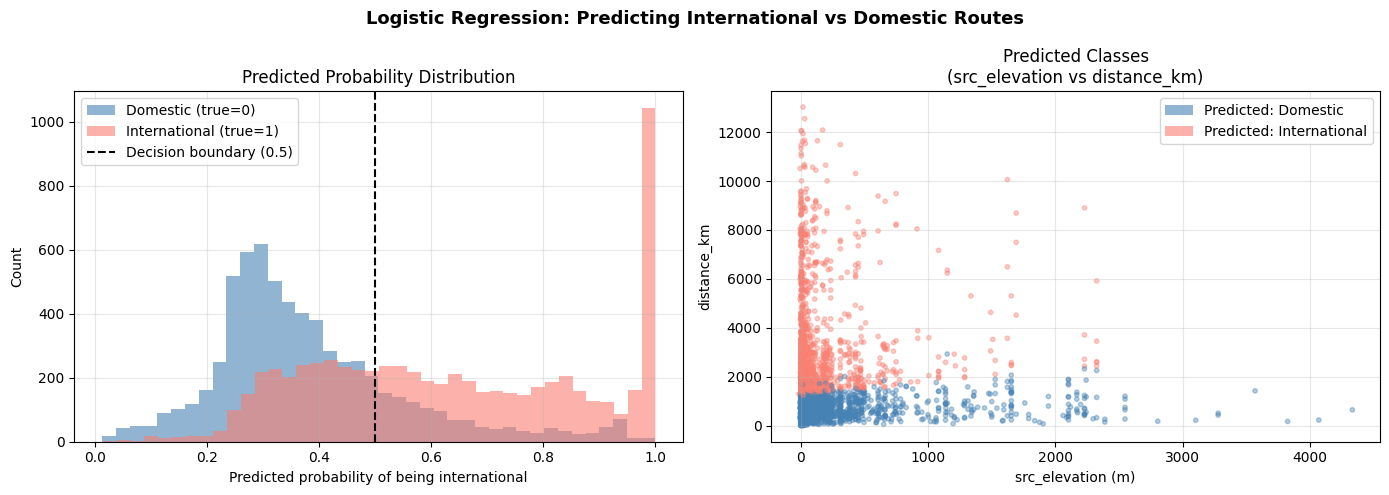

In [ ]:
# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: predicted probability distribution by true class
ax1 = axes[0]
ax1.hist(y_log_pred_proba[y_log_test == 0], bins=40, alpha=0.6,
         color='steelblue', label='Domestic (true=0)')
ax1.hist(y_log_pred_proba[y_log_test == 1], bins=40, alpha=0.6,
         color='salmon', label='International (true=1)')
ax1.axvline(0.5, color='black', linestyle='--', linewidth=1.5,
            label='Decision boundary (0.5)')
ax1.set_xlabel('Predicted probability of being international')
ax1.set_ylabel('Count')
ax1.set_title('Predicted Probability Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: src_elevation vs distance_km coloured by predicted class
ax2 = axes[1]
sample_size = min(3000, len(y_log_test))
idx = np.random.choice(len(y_log_test), size=sample_size, replace=False)
colors = ['steelblue' if p == 0 else 'salmon' for p in y_log_pred[idx]]
ax2.scatter(X_log_test[idx, 0], X_log_test[idx, 2],   # src_elevation vs distance_km
            c=colors, alpha=0.4, s=10)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.6, label='Predicted: Domestic'),
    Patch(facecolor='salmon',    alpha=0.6, label='Predicted: International')
]
ax2.legend(handles=legend_elements)
ax2.set_xlabel('src_elevation (m)')
ax2.set_ylabel('distance_km')
ax2.set_title('Predicted Classes\n(src_elevation vs distance_km)')
ax2.grid(alpha=0.3)

plt.suptitle('Logistic Regression: Predicting International vs Domestic Routes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Loss functions ─────────────────────────────────────────────────────────
abs_loss = 1 - np.mean(y_log_pred == y_log_test)
ll       = log_loss(y_log_test, y_log_pred_proba)

print('Logistic Regression Loss Functions')
print(f'  Absolute loss (1 − accuracy): {abs_loss:.4f}')
print(f'  Log loss                    : {ll:.4f}')
print(f'  Accuracy                    : {1 - abs_loss:.4f}')

Logistic Regression Loss Functions
  Absolute loss (1 − accuracy): 0.2722
  Log loss                    : 0.5456
  Accuracy                    : 0.7278


**Interpretation of Results**

Even with only elevation and distance as predictors, the logistic model classifies domestic vs international routes at a reasonable accuracy (0.7239). The distance_km coefficient is strongly positive — longer routes are more likely to be international. Both elevation features carry negative coefficients, meaning high-elevation airports lean toward domestic service, consistent with what we observed in the regression models. This reinforces the infrastructure story: high-altitude airports, often in mountainous or landlocked regions, tend to serve local rather than international traffic.

## Conclusion

The single linear regression showed us that airport elevation alone is a poor
predictor of route distance, with an R² of just 0.0048. This was an expected but important finding — it confirmed that altitude by itself carries very little information about how far a flight travels. The key takeaway is that elevation shapes route behavior indirectly, as a geographic constraint rather than a direct driver.

The real insight came when geographic features were added incorporating latitude and longitude differences between source and destination airports, the multiple linear regression model jumped to an R² of 0.8468, demonstrating that the angular separation between two airports is far more predictive of route distance than the elevation of either one.

The logistic regression further extended this by showing that elevation and distance together can classify domestic versus international routes at 72% accuracy, suggesting that the physical characteristics of a route carry enough signal to distinguish its type even without any airline or schedule information.